# 주성분 분석 (PCA)

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [12]:
score = {"국어": [73, 52, 75, 64, 45, 32, 48, 15, 46, 98],
         "영어": [33, 70, 83, 80, 40, 33, 38, 23, 62, 88],
         "수학": [18, 38, 32, 33, 68, 50, 48, 77, 85, 90],
         "과학": [22, 20, 34, 32, 52, 48, 50, 76, 68, 72]}
df = pd.DataFrame(score)
df

,국어,영어,수학,과학
0,73,33,18,22
1,52,70,38,20
2,75,83,32,34
3,64,80,33,32
4,45,40,68,52
5,32,33,50,48
6,48,38,48,50
7,15,23,77,76
8,46,62,85,68
9,98,88,90,72


In [13]:
df['평균'] = df.apply(np.mean, axis = 1)
df.sort_values('평균', ascending = False)

,국어,영어,수학,과학,평균
9,98,88,90,72,87.00
8,46,62,85,68,65.25
2,75,83,32,34,56.00
3,64,80,33,32,52.25
4,45,40,68,52,51.25
7,15,23,77,76,47.75
6,48,38,48,50,46.00
1,52,70,38,20,45.00
5,32,33,50,48,40.75
0,73,33,18,22,36.50


In [14]:
from sklearn.preprocessing import StandardScaler # scaling
from sklearn.decomposition import PCA            # pca

x = df.drop(['평균'], axis=1)

x_std = StandardScaler().fit_transform(x) # Scaling
x_std

array([[ 0.81217633, -0.95760849, -1.52926653, -1.32255795],
       [-0.12495021,  0.65291488, -0.67730746, -1.42669637],
       [ 0.90142648,  1.21877444, -0.93289518, -0.69772742],
       [ 0.41055067,  1.08819147, -0.89029723, -0.80186584],
       [-0.43732572, -0.65291488,  0.60063114,  0.23951837],
       [-1.01745167, -0.95760849, -0.16613202,  0.03124153],
       [-0.3034505 , -0.7399702 , -0.25132793,  0.13537995],
       [-1.77607792, -1.39288508,  0.98401273,  1.48917942],
       [-0.39270064,  0.30469361,  1.32479635,  1.07262574],
       [ 1.92780317,  1.43641274,  1.53778612,  1.28090258]])

In [15]:
df_std = pd.DataFrame(x_std)
var_names = ['Korean', 'English', 'Math', 'Science']
df_std.columns = var_names
df_std

,Korean,English,Math,Science
0,0.812176,-0.957608,-1.529267,-1.322558
1,-0.124950,0.652915,-0.677307,-1.426696
2,0.901426,1.218774,-0.932895,-0.697727
3,0.410551,1.088191,-0.890297,-0.801866
4,-0.437326,-0.652915,0.600631,0.239518
5,-1.017452,-0.957608,-0.166132,0.031242
6,-0.303450,-0.739970,-0.251328,0.135380
7,-1.776078,-1.392885,0.984013,1.489179
8,-0.392701,0.304694,1.324796,1.072626
9,1.927803,1.436413,1.537786,1.280903


In [17]:
df_std['Average'] = df_std.apply(np.mean, axis = 1)
df_std.sort_values('Average', ascending = False)

,Korean,English,Math,Science,Average
9,1.927803,1.436413,1.537786,1.280903,1.545726
8,-0.392701,0.304694,1.324796,1.072626,0.577354
2,0.901426,1.218774,-0.932895,-0.697727,0.122395
3,0.410551,1.088191,-0.890297,-0.801866,-0.048355
4,-0.437326,-0.652915,0.600631,0.239518,-0.062523
7,-1.776078,-1.392885,0.984013,1.489179,-0.173943
6,-0.303450,-0.739970,-0.251328,0.135380,-0.289842
1,-0.124950,0.652915,-0.677307,-1.426696,-0.394010
5,-1.017452,-0.957608,-0.166132,0.031242,-0.527488
0,0.812176,-0.957608,-1.529267,-1.322558,-0.749314


In [18]:
pca = PCA(n_components = 1) # 1-dim
df_std["pca"] = pca.fit_transform(x_std)
df_std

,Korean,English,Math,Science,Average,pca
0,0.812176,-0.957608,-1.529267,-1.322558,-0.749314,-1.654429
1,-0.124950,0.652915,-0.677307,-1.426696,-0.394010,-1.411997
2,0.901426,1.218774,-0.932895,-0.697727,0.122395,-1.782881
3,0.410551,1.088191,-0.890297,-0.801866,-0.048355,-1.553413
4,-0.437326,-0.652915,0.600631,0.239518,-0.062523,0.909461
5,-1.017452,-0.957608,-0.166132,0.031242,-0.527488,0.734053
6,-0.303450,-0.739970,-0.251328,0.135380,-0.289842,0.348948
7,-1.776078,-1.392885,0.984013,1.489179,-0.173943,2.743962
8,-0.392701,0.304694,1.324796,1.072626,0.577354,1.440378
9,1.927803,1.436413,1.537786,1.280903,1.545726,0.225918


In [19]:
df_std.cov()

,Korean,English,Math,Science,Average,pca
Korean,1.111111,0.810423,-0.187179,-0.292050,0.360576,-1.074026
English,0.810423,1.111111,0.012361,-0.175776,0.439530,-0.868283
Math,-0.187179,0.012361,1.111111,1.034938,0.492808,1.313886
Science,-0.292050,-0.175776,1.034938,1.111111,0.419556,1.433421
Average,0.360576,0.439530,0.492808,0.419556,0.428118,0.201250
pca,-1.074026,-0.868283,1.313886,1.433421,0.201250,2.385045


In [20]:
pca.components_.T # loading vector

array([[-0.45031691],
       [-0.36405299],
       [ 0.55088531],
       [ 0.60100372]])

In [21]:
df_std.sort_values('pca', ascending = False)

,Korean,English,Math,Science,Average,pca
7,-1.776078,-1.392885,0.984013,1.489179,-0.173943,2.743962
8,-0.392701,0.304694,1.324796,1.072626,0.577354,1.440378
4,-0.437326,-0.652915,0.600631,0.239518,-0.062523,0.909461
5,-1.017452,-0.957608,-0.166132,0.031242,-0.527488,0.734053
6,-0.303450,-0.739970,-0.251328,0.135380,-0.289842,0.348948
9,1.927803,1.436413,1.537786,1.280903,1.545726,0.225918
1,-0.124950,0.652915,-0.677307,-1.426696,-0.394010,-1.411997
3,0.410551,1.088191,-0.890297,-0.801866,-0.048355,-1.553413
0,0.812176,-0.957608,-1.529267,-1.322558,-0.749314,-1.654429
2,0.901426,1.218774,-0.932895,-0.697727,0.122395,-1.782881


In [22]:
# 2차원으로의 축소
pca2 = PCA(n_components = 2) ### 2-dim

pca2_scores = pca2.fit_transform(x_std)
df_std[["pca2_1", "pca2_2"]] = pca2_scores
df_std

,Korean,English,Math,Science,Average,pca,pca2_1,pca2_2
0,0.812176,-0.957608,-1.529267,-1.322558,-0.749314,-1.654429,-1.654429,-1.333733
1,-0.124950,0.652915,-0.677307,-1.426696,-0.394010,-1.411997,-1.411997,-0.473064
2,0.901426,1.218774,-0.932895,-0.697727,0.122395,-1.782881,-1.782881,0.560802
3,0.410551,1.088191,-0.890297,-0.801866,-0.048355,-1.553413,-1.553413,0.203171
4,-0.437326,-0.652915,0.600631,0.239518,-0.062523,0.909461,0.909461,-0.277481
5,-1.017452,-0.957608,-0.166132,0.031242,-0.527488,0.734053,0.734053,-1.198074
6,-0.303450,-0.739970,-0.251328,0.135380,-0.289842,0.348948,0.348948,-0.687984
7,-1.776078,-1.392885,0.984013,1.489179,-0.173943,2.743962,2.743962,-0.828536
8,-0.392701,0.304694,1.324796,1.072626,0.577354,1.440378,1.440378,0.967273
9,1.927803,1.436413,1.537786,1.280903,1.545726,0.225918,0.225918,3.067625


In [23]:
a = pca2.components_.T
a

array([[-0.45031691,  0.52803829],
       [-0.36405299,  0.62209139],
       [ 0.55088531,  0.45815145],
       [ 0.60100372,  0.35252676]])

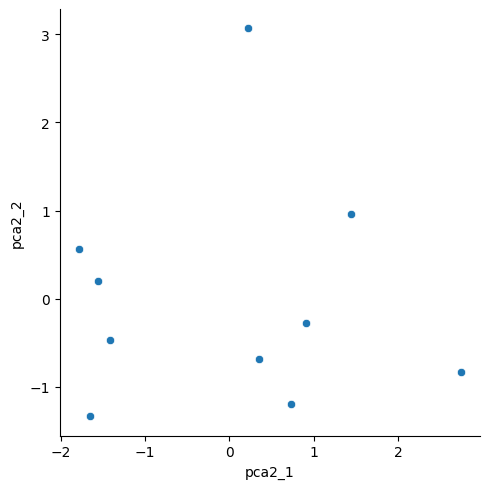

In [24]:
sns.relplot(df_std, x = "pca2_1", y = "pca2_2")
plt.show()

In [26]:
# 몇차원으로 줄일지 확인 (주성분이 분산을 얼마나 설명하고 있는지 확인)
pca2.explained_variance_ratio_

array([0.53663511, 0.38441303])

<function matplotlib.pyplot.show(close=None, block=None)>

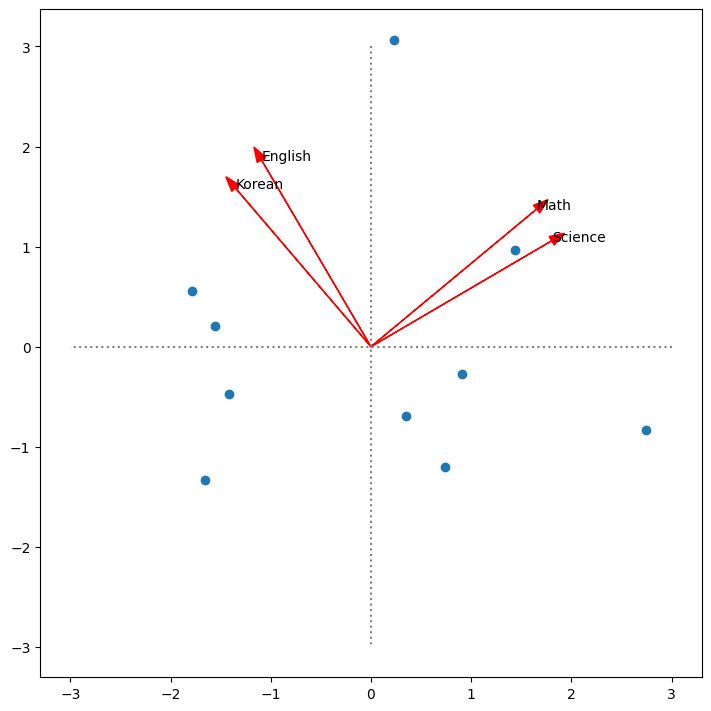

In [27]:
fig, ax = plt.subplots(figsize=(7, 7), layout='constrained')
ax.scatter(df_std.pca2_1.values, df_std.pca2_2.values)
for i, vnames in (enumerate(var_names)):
    plt.arrow(x = 0, y = 0, dx = 3 * a[i,0], dy = 3 * a[i,1], color = 'r', head_width = 0.1)
    plt.text(3 * a[i,0], 3 * a[i,1], vnames)

plt.vlines(0, 3, -3, linestyle = "dotted", colors = "gray")
plt.hlines(0, 3, -3, linestyle = "dotted", colors = "gray")
plt.show

# PCA Application to IRIS Data

In [37]:
from sklearn import datasets
iris = datasets.load_iris()

X = iris.data
y = iris.target

# Convert into the Categorical Objects
yc = pd.Series(y, dtype = "category")
yc = yc.cat.rename_categories({0:'setosa', 1:'versicolor', 2:'virginica'})
yc

# Scaling
x_std = StandardScaler().fit_transform(X) # scaling

In [38]:
pca = PCA(n_components = 4)
pca_features = pca.fit_transform(x_std)

In [39]:
loadings = pca.components_
loadings

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199],
       [ 0.71956635, -0.24438178, -0.14212637, -0.63427274],
       [-0.26128628,  0.12350962,  0.80144925, -0.52359713]])

In [40]:
# Scree Plot 축소차원의 선택
ratio = pca.explained_variance_ratio_
ratio

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

In [41]:
np.round(np.cumsum(ratio), 3)

array([0.73 , 0.958, 0.995, 1.   ])

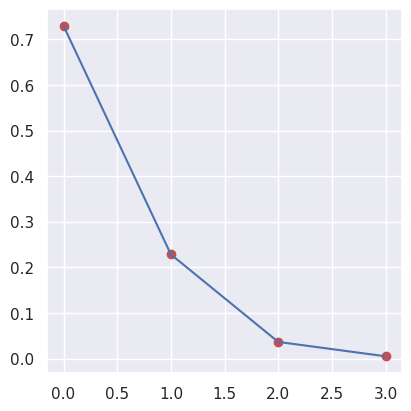

In [42]:
fig, ax = plt.subplots(figsize=(4, 4), layout='constrained')
ax.plot(ratio)
ax.scatter(x = np.arange(4), y = ratio, color = "r")
plt.show()

In [43]:
iris_pca = pd.DataFrame(pca_features[:,:2])
iris_pca.columns = ["PC1", "PC2"]
iris_pca["target"] = yc
iris_pca

,PC1,PC2,target
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa
...,...,...,...
145,1.870503,0.386966,virginica
146,1.564580,-0.896687,virginica
147,1.521170,0.269069,virginica
148,1.372788,1.011254,virginica


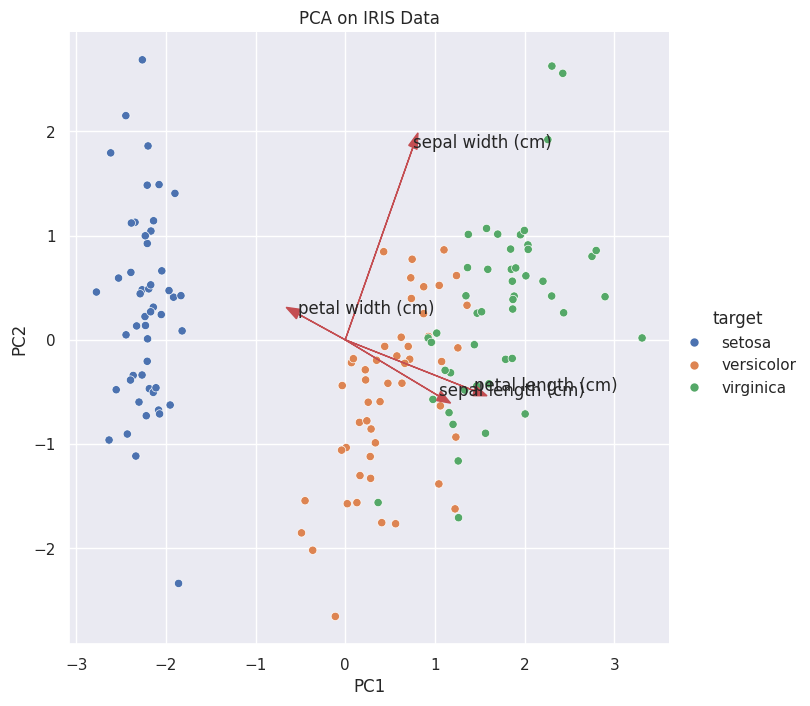

In [44]:
sns.set_theme()
rel = sns.relplot(data = iris_pca, x = "PC1", y = "PC2", hue = "target", height = 7)
rel.set(title = "PCA on IRIS Data")


var_names = iris.feature_names
for i, vnames in (enumerate(var_names)):
    plt.arrow(x = 0, y = 0, dx = 2 * loadings[i,0], dy = 2 * loadings[i,1], color = 'r', head_width = 0.1)
    plt.text(2 * loadings[i,0], 2 * loadings[i,1], vnames)
plt.show()

## PCA의 계산 - Eigenvalue Decomposition

In [45]:
from numpy import linalg as LA

In [46]:
# Covariance Matrix
S = np.cov(X.T)
S

array([[ 0.68569351, -0.042434  ,  1.27431544,  0.51627069],
       [-0.042434  ,  0.18997942, -0.32965638, -0.12163937],
       [ 1.27431544, -0.32965638,  3.11627785,  1.2956094 ],
       [ 0.51627069, -0.12163937,  1.2956094 ,  0.58100626]])

In [47]:
# Eigen-Decomposition
eval1, evec1 = LA.eig(S)
eval1

array([4.22824171, 0.24267075, 0.0782095 , 0.02383509])

In [48]:
evec1.T

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [-0.65658877, -0.73016143,  0.17337266,  0.07548102],
       [-0.58202985,  0.59791083,  0.07623608,  0.54583143],
       [ 0.31548719, -0.3197231 , -0.47983899,  0.75365743]])

In [49]:
loadings

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199],
       [ 0.71956635, -0.24438178, -0.14212637, -0.63427274],
       [-0.26128628,  0.12350962,  0.80144925, -0.52359713]])

In [50]:
R = np.corrcoef(X.T)
R

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [51]:
eval2, evec2 = LA.eig(R)
evec2.T

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [-0.37741762, -0.92329566, -0.02449161, -0.06694199],
       [-0.71956635,  0.24438178,  0.14212637,  0.63427274],
       [ 0.26128628, -0.12350962, -0.80144925,  0.52359713]])

In [52]:
eval2

array([2.91849782, 0.91403047, 0.14675688, 0.02071484])

In [53]:
ratio

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

In [54]:
eval2/np.sum(eval2)

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

## Kernel PCA

In [55]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components = 2, kernel="rbf", gamma = .5)
kpca_features = kpca.fit_transform(x_std)

iris_kpca = pd.DataFrame(kpca_features)
iris_kpca.columns = ["direction1", "direction2"]
iris_kpca["target"] = yc
iris_kpca

,direction1,direction2,target
0,0.775161,0.025887,setosa
1,0.603423,-0.047449,setosa
2,0.718075,-0.010696,setosa
3,0.645281,-0.025016,setosa
4,0.741901,0.036525,setosa
...,...,...,...
145,-0.365034,0.579580,virginica
146,-0.350080,-0.114794,virginica
147,-0.484257,0.464438,virginica
148,-0.224392,0.442376,virginica


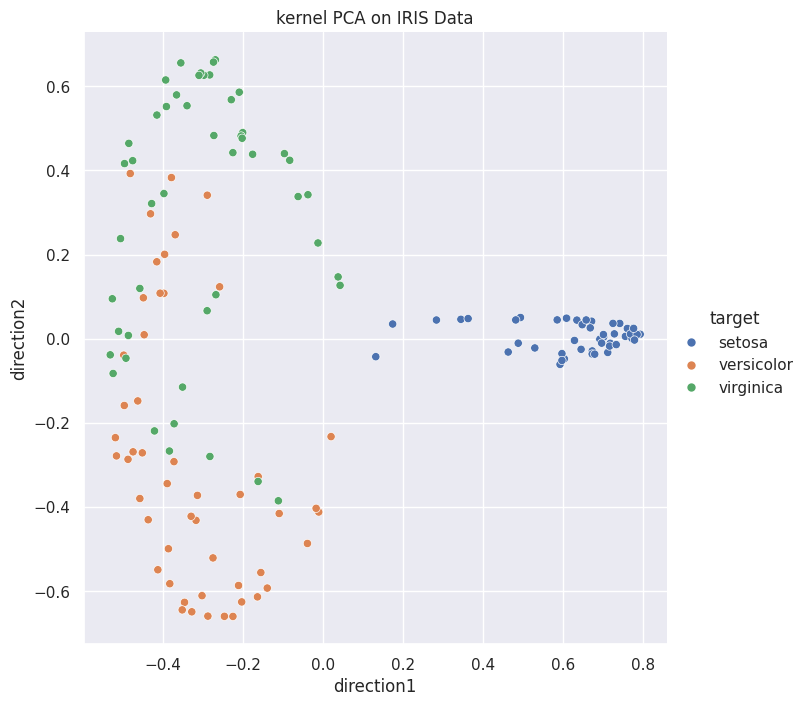

In [56]:
sns.set_theme()
rel = sns.relplot(data = iris_kpca,
                  x = "direction1", y = "direction2",
                  hue = "target", height = 7)
rel.set(title = "kernel PCA on IRIS Data")
plt.show()

## MDS (Multi-Dimensional Scaling)

In [57]:
from sklearn.manifold import MDS

mds = MDS(n_components = 2)
x_mds = mds.fit_transform(X)

In [58]:
iris_mds = pd.DataFrame(x_mds)
iris_mds.columns = ["direction1", "direction2"]
iris_mds["target"] = yc
iris_mds

,direction1,direction2,target
0,-2.616213,-0.714802,setosa
1,-2.450070,-1.204081,setosa
2,-2.647989,-1.199940,setosa
3,-2.437130,-1.321910,setosa
4,-2.672251,-0.708066,setosa
...,...,...,...
145,1.681020,1.064163,virginica
146,1.574884,0.223368,virginica
147,1.602565,0.758693,virginica
148,1.567960,1.243107,virginica


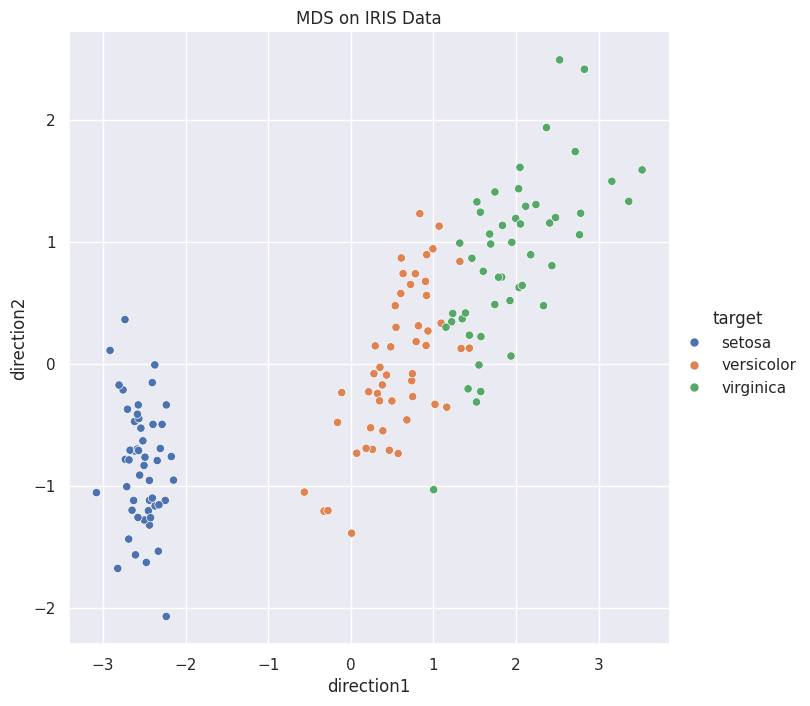

In [59]:
sns.set_theme()
rel = sns.relplot(data = iris_mds,
                  x = "direction1", y = "direction2",
                  hue = "target", height = 7)
rel.set(title = "MDS on IRIS Data")
plt.show()

In [63]:
# Non-metric MDS
mds_n = MDS(n_components = 2, metric = False)
x_mds = mds_n.fit_transform(X)

In [64]:
iris_mds = pd.DataFrame(x_mds)
iris_mds.columns = ["direction1", "direction2"]
iris_mds["target"] = yc
iris_mds

,direction1,direction2,target
0,0.086397,0.449219,setosa
1,-0.093001,0.011625,setosa
2,0.439797,0.121401,setosa
3,0.064812,-0.492329,setosa
4,0.174836,0.082103,setosa
...,...,...,...
145,0.536097,-0.518753,virginica
146,0.403577,0.307667,virginica
147,0.145804,-0.197883,virginica
148,-0.132140,-0.091837,virginica


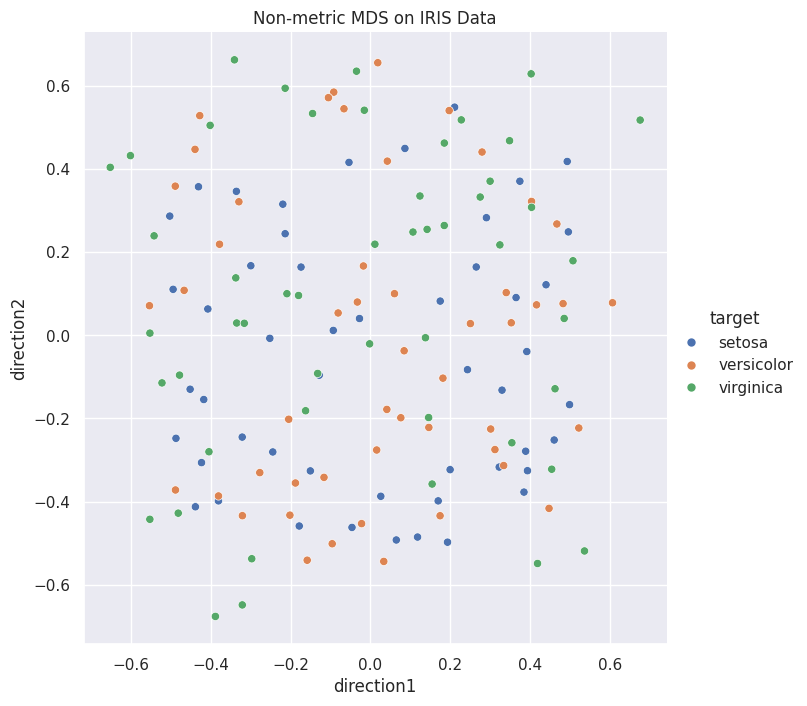

In [65]:
sns.set_theme()
rel = sns.relplot(data = iris_mds,
                  x = "direction1", y = "direction2",
                  hue = "target", height = 7)
rel.set(title = "Non-metric MDS on IRIS Data")
plt.show()

## t-SNE (t-Stochastic Neighbor Embedding)

In [66]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, perplexity = 20)
x_tsne = tsne.fit_transform(X)

iris_tsne = pd.DataFrame(x_tsne)
iris_tsne.columns = ["direction1", "direction2"]
iris_tsne["target"] = yc

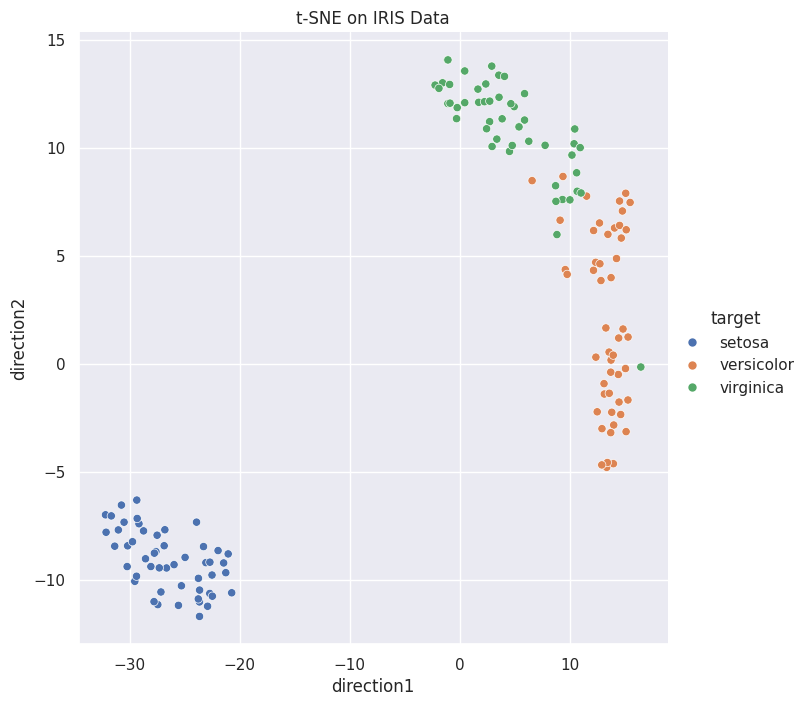

In [67]:
rel = sns.relplot(data = iris_tsne,
                  x = "direction1", y = "direction2",
                  hue = "target", height = 7)
rel.set(title = "t-SNE on IRIS Data")
plt.show()

## LLE (Local Linear Embedding)

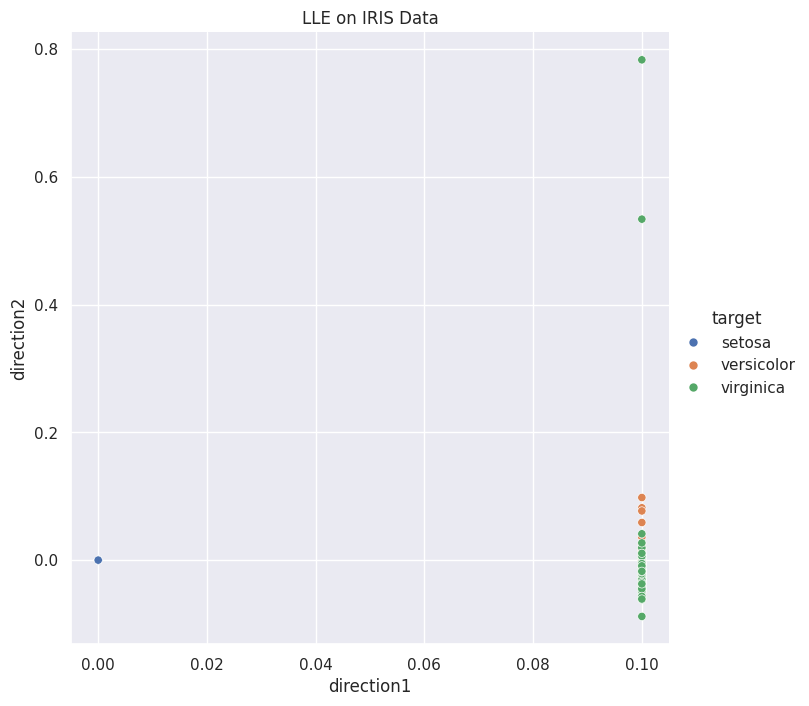

In [69]:
from sklearn.manifold import LocallyLinearEmbedding as LLE

lle = LLE(n_components = 2)
x_lle = lle.fit_transform(X)

iris_lle = pd.DataFrame(x_lle)
iris_lle.columns = ["direction1", "direction2"]
iris_lle["target"] = yc

rel = sns.relplot(data = iris_lle,
                  x = "direction1", y = "direction2",
                  hue = "target", height = 7)
rel.set(title = "LLE on IRIS Data")
plt.show()

# Handwritten Digits Data

In [90]:
from sklearn.datasets import load_digits

digits = load_digits(n_class = 6)
X_digits, y_digits = digits.data, digits.target

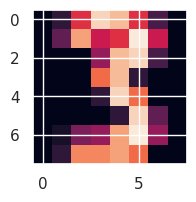

In [97]:
# Data 형태
plt.figure(figsize=(2, 2))
plt.imshow(X_digits[9].reshape(8, 8))
plt.show()

In [101]:
X_digits[9].reshape(8,8) # 8x8 pixel 에 해당하는 color 값 : X

array([[ 0.,  2.,  9., 15., 14.,  9.,  3.,  0.],
       [ 0.,  4., 13.,  8.,  9., 16.,  8.,  0.],
       [ 0.,  0.,  0.,  6., 14., 15.,  3.,  0.],
       [ 0.,  0.,  0., 11., 14.,  2.,  0.,  0.],
       [ 0.,  0.,  0.,  2., 15., 11.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  2., 15.,  4.,  0.],
       [ 0.,  1.,  5.,  6., 13., 16.,  6.,  0.],
       [ 0.,  2., 12., 12., 13., 11.,  0.,  0.]])

In [99]:
y_digits[9] # label (3) : Y

3

In [102]:
pca = PCA(n_components = 2)
kpca = KernelPCA(n_components = 2, kernel = "rbf", gamma = 10)
mds = MDS(n_components = 2)
nmds = MDS(n_components = 2, metric = False)
tsne = TSNE(n_components = 2, perplexity = 20)
lle = LLE(n_components=2)

In [103]:
x_pca  = pca.fit_transform(X_digits)
x_kpca = kpca.fit_transform(X_digits)
x_mds  = mds.fit_transform(X_digits)
x_nmds = nmds.fit_transform(X_digits)
x_tsne = tsne.fit_transform(X_digits)
x_lle  = lle.fit_transform(X_digits)

In [104]:
digits_pca  = pd.DataFrame(x_pca)
digits_kpca = pd.DataFrame(x_kpca)
digits_mds  = pd.DataFrame(x_mds)
digits_nmds = pd.DataFrame(x_nmds)
digits_tsne = pd.DataFrame(x_tsne)
digits_lle  = pd.DataFrame(x_lle)

digits_pca.columns  = ["direction1", "direction2"]
digits_kpca.columns = ["direction1", "direction2"]
digits_mds.columns  = ["direction1", "direction2"]
digits_nmds.columns = ["direction1", "direction2"]
digits_tsne.columns = ["direction1", "direction2"]
digits_lle.columns  = ["direction1", "direction2"]

digits_pca["target"]  = y_digits
digits_kpca["target"] = y_digits
digits_mds["target"]  = y_digits
digits_nmds["target"] = y_digits
digits_tsne["target"] = y_digits
digits_lle["target"]  = y_digits

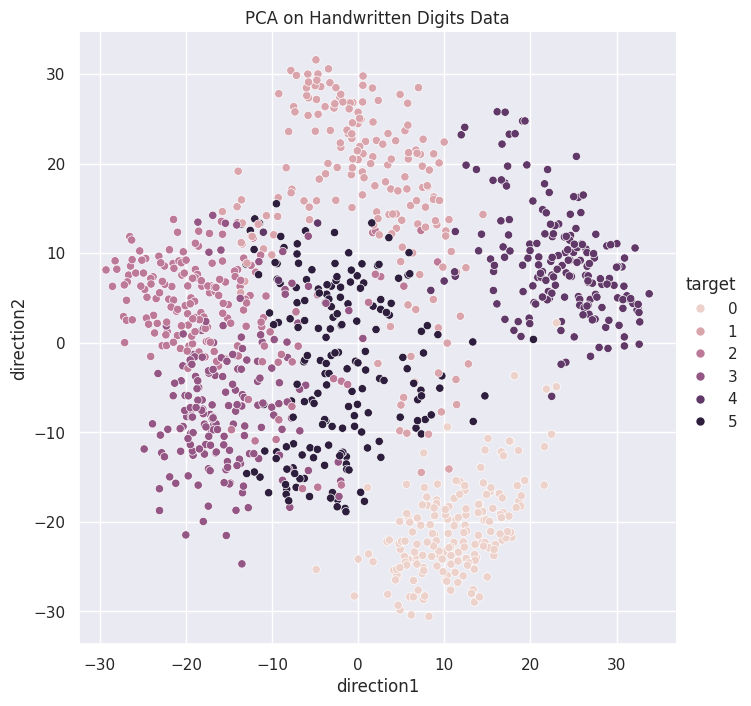

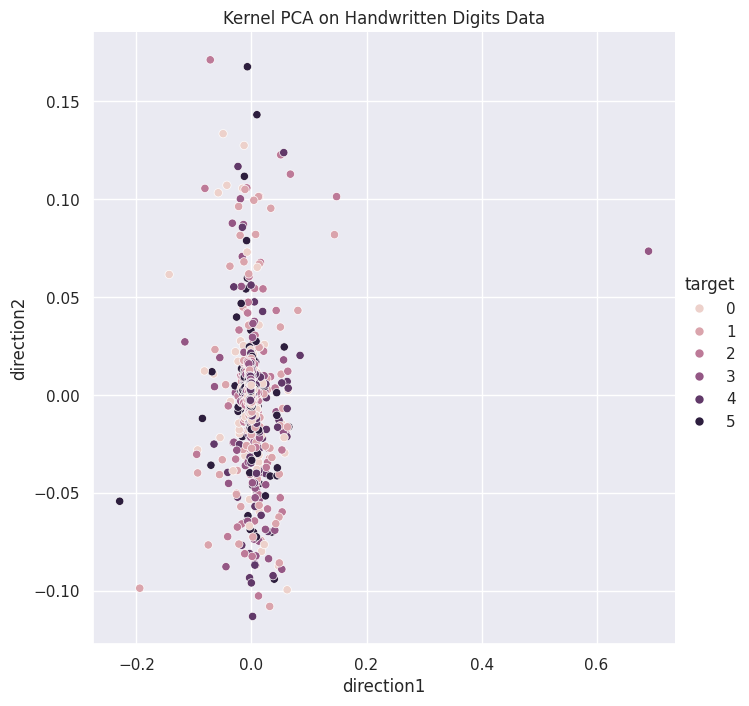

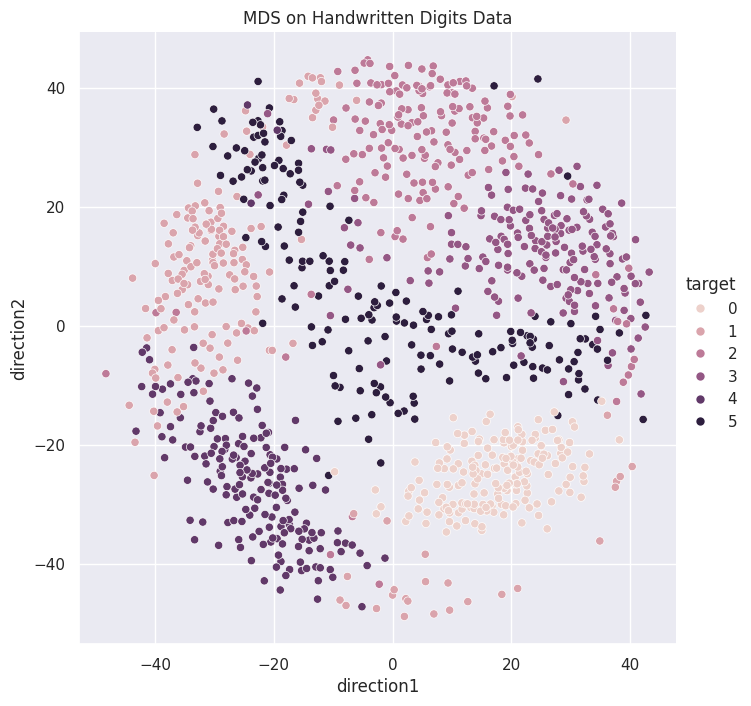

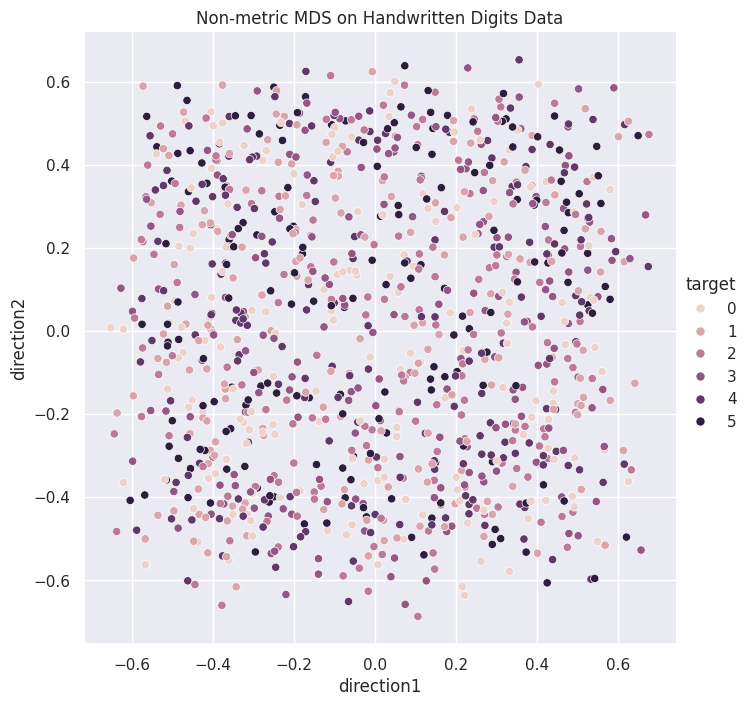

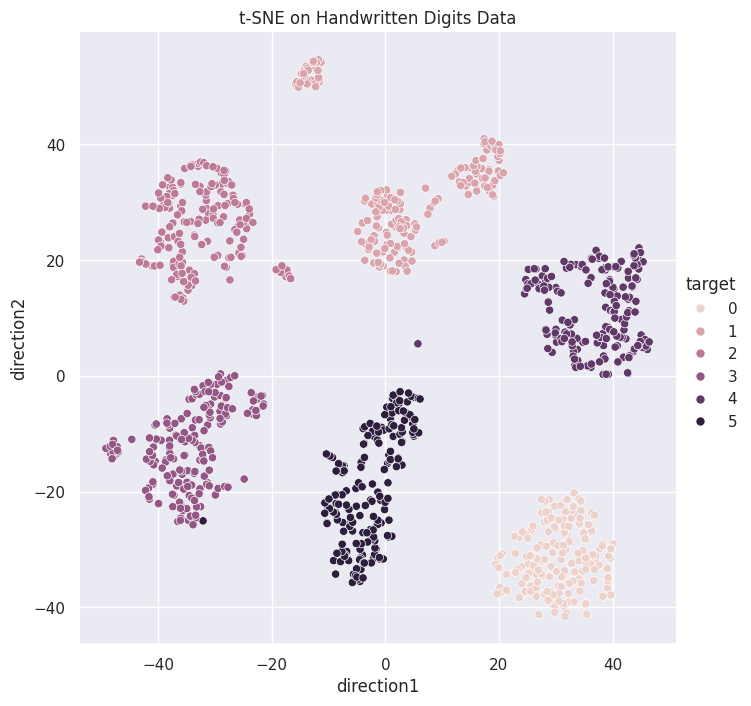

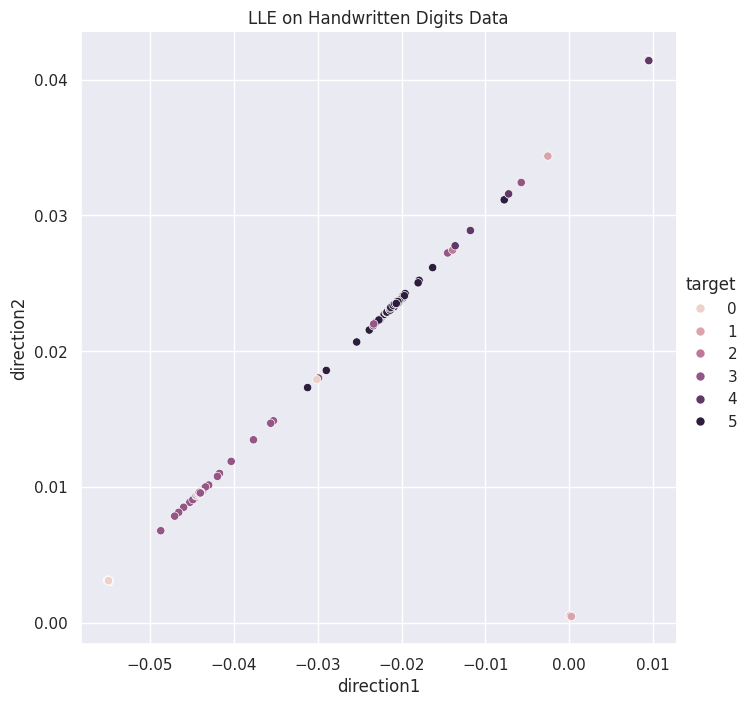

In [106]:
embedding_dataframes = {
    'PCA': digits_pca,
    'Kernel PCA': digits_kpca,
    'MDS': digits_mds,
    'Non-metric MDS': digits_nmds,
    't-SNE': digits_tsne,
    'LLE': digits_lle
}

for method, df in embedding_dataframes.items():
    sns.relplot(data=df, x="direction1", y="direction2", hue="target", height=7)
    plt.title(f"{method} on Handwritten Digits Data")
    plt.show()
